In [1]:
import wandb

import pandas as pd

from tqdm import tqdm

from matplotlib import pyplot as plt

import numpy as np 

from xaikd import models, datasets

from torch.utils.data import DataLoader
from xaikd.utils import metrics

In [13]:
api = wandb.Api()

In [14]:
EXPERIMENT_GROUP = "./artifacts/2023-09-s13/experiments/distillation-layerwise/run4-parameterization-basis-based-policy"

In [31]:
def read_data(
    teacher,
    student,
    policy,
    lambda_task,
    lambda_kd,
    arr_lambda_layer,
    dataset,
    training_size,
    verbose=False,
    
):
    
    
    runs = api.runs(
        f'p16i/xaikd-distillation-layerwise',
        {
        "$and": [
            {"group": EXPERIMENT_GROUP},
            {"config.teacher": teacher},
            {"config.student": student},
            {"config.lambda_task": lambda_task},
            {"config.lambda_kd": lambda_kd},
            {"config.lambda_layer": {"$in": arr_lambda_layer}},
            {"config.policy": policy},
            {"config.training_size": training_size},
            {"config.dataset": dataset},
#             {"config.seed": 2},
        ]}
    )
    
    if verbose:
        print(f"we have {len(runs)} runs")
    
    rows = []
    
    for run in runs:
        seed = run.config["seed"]
         
        
        k = np.argmax(run.summary["arr_metrics"]["val_acc"]["value"])
        best_val_acc = run.summary["arr_metrics"]["val_acc"]["value"][k]
        best_val_agreement = run.summary["arr_metrics"]["val_agreement"]["value"][k]
        best_val_agreement_on_teacher_correct = run.summary["arr_metrics"]["val_agreement_on_teacher_correct"]["value"][k]


        rows.append(
            dict(
                seed=seed, 
                lambda_task=run.config["lambda_task"],
                lambda_kd=run.config["lambda_kd"],
                lambda_layer=run.config["lambda_layer"],
                val_acc=best_val_acc, 
                val_agreement=best_val_agreement,
                val_agreement_on_teacher_correct=best_val_agreement_on_teacher_correct,
                teacher_acc=run.summary["teacher_acc"],
                policy=run.config["policy"]
            )
        )

    
    df = pd.DataFrame(rows)
    
        
    df = df.groupby(by="lambda_layer").agg(
        {
            "val_acc": ["mean", "std", "count"],
            "val_agreement": ["mean", "std", "count"],
            "val_agreement_on_teacher_correct": ["mean", "std", "count"],
            "teacher_acc": ["mean"]
        }
    ).reset_index()
    if verbose:
        print(f"df.shape: {df.shape}")
    return df

summary = read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    lambda_task=0.0,
    lambda_kd=1.0,
    arr_lambda_layer=[0.],
    policy="basis-student-identity:prca-sortabs--uncentered",
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",

)

summary

we have 2 runs
df.shape: (1, 11)


lambda_layer val_acc                 val_agreement                  \
                  mean       std count          mean       std count   
0            0    0.52  0.002828     2         0.518  0.002828     2   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                            0.398  0.002828     2       0.624

In [33]:
read_data(
    teacher="cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
    lambda_task=0.0,
    lambda_kd=1.0,
    arr_lambda_layer=[0.],
    policy="basis-student-identity:random--uncentered",
    training_size=1.0,
    verbose=True,
    dataset="cifar100-people",

)


we have 3 runs
df.shape: (1, 11)


lambda_layer   val_acc                 val_agreement                  \
                    mean       std count          mean       std count   
0            0  0.518667  0.010263     3      0.518667  0.017243     3   

  val_agreement_on_teacher_correct                 teacher_acc  
                              mean       std count        mean  
0                            0.402  0.011136     3       0.624

# Comparison on `cifar100-resnet18-wb15`

[warning] policy=basis:pca--uncentered: [3 2 3 3 3 3 2 2 2 3]
[warning] policy=basis-student-identity:pca--uncentered: [3 2 3 3 3 3 2 2 2 3]
[warning] policy=basis-student-linearnb:pca--uncentered: [3 2 3 3 3 3 2 2 2 3]
[warning] policy=basis-student-linearnbinner:pca--uncentered: [3 2 3 3 3 3 2 2 2 3]
[warning] policy=basis:prca-sortabs--uncentered: [2 3 2 3 2 3 2 2 2 2]
[warning] policy=basis-student-identity:prca-sortabs--uncentered: [2 3 2 3 2 3 2 2 2 2]
[warning] policy=basis-student-linearnb:prca-sortabs--uncentered: [2 3 2 3 2 3 2 2 2 2]
[warning] policy=basis-student-linearnbinner:prca-sortabs--uncentered: [2 3 2 3 2 3 2 2 2 2]
[warning] policy=basis:random--uncentered: [3 2 3 3 3 2 3 3 3 3]
[warning] policy=basis-student-identity:random--uncentered: [3 2 3 3 3 2 3 3 3 3]
[warning] policy=basis-student-linearnb:random--uncentered: [3 2 3 3 3 2 3 3 3 3]
[warning] policy=basis-student-linearnbinner:random--uncentered: [3 2 3 3 3 2 3 3 3 3]


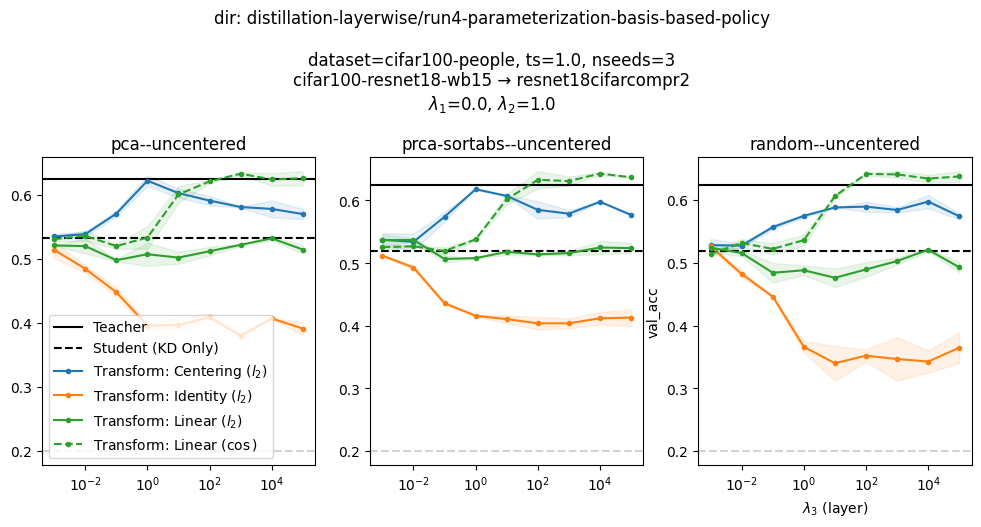

In [43]:
def ls(policy):
    if "inner" in policy:
        return "--"
    else:
        return "-"
    
def alias(policy):
    dd = {
        "basis": "Centering ($l_2$)",
        "basis-student-identity": "Identity ($l_2$)",
        "basis-student-linearnb": "Linear ($l_2$)",
        "basis-student-linearnbinner": "Linear ($\cos$)",
    }
    
    return dd.get(policy, policy)

def color(policy):
    return None

#     if policy == "basis-student-identity":
#         return "gray"
#     else:
#         return None
    
def viz_distillation(
    teacher, student, basis_mode="uncentered", show_legend=True,
    training_size=1.0
):
        
    dataset = "cifar100-people"
    lambda_kd = 1.0
    lambda_task = 0.0
    arr_lambda_layer = [
        0, 0.001, 0.01, 
        0.1, 1.0, 10.0,
        100.0, 
        1000.0, 10000.0,
        100000.0,
#         1_000_000.0,
#         10_000_000.0, 100_000_000.0
    ]
    
    arr_bases = [
        "pca",
        "prca-sortabs",
        "random"
    ]
    
    policies = [ 
        "basis",

        "basis-student-identity",
        
        "basis-student-linearnb",
        "basis-student-linearnbinner",
        
#         "basis-student-ortho",
#         "basis-student-orthoinner",
    ]

        
    
    arr_lambda_layer = arr_lambda_layer
    policies = policies
        

    col = "val_acc"
    
    ncols = len(arr_bases)
    nrows = 1
    
    plt.figure(figsize=(4*ncols, 4*nrows))
    
    dirslug = "/".join(f"{EXPERIMENT_GROUP}".split("/")[-2:])

    count = None
    
    for bix, basis in enumerate(arr_bases):
        plt.subplot(nrows, ncols, bix + 1)
        plt.title(f"{basis}--{basis_mode}")
        

        for pix, policy in enumerate(policies):
            slug = f"{policy}:{basis}--{basis_mode}"
            df = read_data(
                teacher=teacher,
                student=student,
                policy=f"{policy}:{basis}--{basis_mode}",
                lambda_task=lambda_task,
                lambda_kd=lambda_kd,
                arr_lambda_layer=arr_lambda_layer,
                dataset=dataset,
                training_size=training_size,
                verbose=False
            )

            if count == None:
                count = df[col]["count"].values[0]
            else:
    #             np.testing.assert_equal(df[col]["count"].values, count)  
                pass 
            if not (df[col]["count"].values == df[col]["count"].values[0]).all() \
                or df[col]["count"].values[0] != count:
                    print(f"[warning] policy={slug}:", df[col]["count"].values)    

            if pix == 0:
                plt.axhline(
                    df["teacher_acc"].values[-1],
                    ls="-",
                    color="k",
                    label="Teacher"
                )

                plt.axhline(
                    df[col]["mean"].values[0],
                    ls="--",
                    color="k",
                    label="Student (KD Only)"
                )
                plt.axhline(0.2, ls="--", color="lightgray")

            # here, we use [1:] to excluding lambda_layer=0
            assert df["lambda_layer"][0] == 0.0
            ticks = df["lambda_layer"][1:]
            mean = df[col]["mean"][1:]
            stderr = df[col]["std"][1:] / (count ** 0.5)


            if "inner" in policy:
                _color = plt.gca().lines[-1].get_color()
            else:
                _color = color(policy)
            
            
            plt.plot(
                ticks,
                mean,
                marker=".",
                label="Transform: " + alias(policy),
                ls=ls(policy),
                color=_color,
            )

            plt.fill_between(
                ticks,
                mean - stderr,
                mean + stderr,
                alpha=0.1,
                color=plt.gca().lines[-1].get_color()
            )
        
    
        if bix == 0:
            plt.legend()

        plt.xscale("log")
    plt.xlabel("$\lambda_3$ (layer)")
    plt.ylabel(col)
    
    plt.suptitle(
        "\n".join([
            f"dir: {dirslug}",
            "",
            f"dataset={dataset}, ts={training_size}, nseeds={count}",
            f"{teacher} → {student}",
            f"$\lambda_1$={lambda_task}, $\lambda_2$={lambda_kd}"
        ]),
        y=1.25,
    )

viz_distillation(
    teacher = "cifar100-resnet18-wb15",
    student="resnet18cifarcompr2",
) 

# Summary

Setup:
$$
 (0.0) \ell_\text{task} + \lambda_2 \ell_\text{KD} + \lambda_3 \ell_\text{layer},
$$
$\lambda_2 = 1$ and $\lambda_3 = \{0, 10^{-3}, 10^{-2}, \dots,  10^5\}$

*Aims:* 
- investigate the transformation of the student features and criteria.


*Conclusion:* 
- Policies `basis` or `basis-student-linearnbinner` leads to good performance. The explanation to this is that using $l_2$, there is additional regularization effect preventing the features from student to grow large, hence limiting learning
    - (insight): it seems sufficient to just distilling angular feature alignments to the student.

*Remark*: 
- some runs are faied, and has the number of seeds are different than others.
- Currently, the accuracy comes from the validation set. Preferbably, we repeat this again using a proper validation/test set.
- `student (KD Only)` setups are different across the bases because the runs were scheduled separately.